## 1.Configuration des chemins du projet


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

from src.paths import RELEVES_PATH, METEO_PATH, OUTPUT_DIR

print(RELEVES_PATH)
print(METEO_PATH)
print(OUTPUT_DIR)

C:\Users\iness\PycharmProjects\PythonProject2\Neovolt-grid-project\volet-datascience\data\raw\releves_consommation.csv
C:\Users\iness\PycharmProjects\PythonProject2\Neovolt-grid-project\volet-datascience\data\raw\meteo.csv
C:\Users\iness\PycharmProjects\PythonProject2\Neovolt-grid-project\volet-datascience\data\output


## 2. Import des bibliothèques

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

 ## 3. Lecture des données

In [6]:
releves = pd.read_csv(RELEVES_PATH)
meteo = pd.read_csv(METEO_PATH)

display(releves.head())
display(meteo.head())

print(releves.shape)
print(meteo.shape)

,id_pdl,date,consommation_kwh,zone
0,PDL-000001,2024-01-01,18.14,Coteaux-Ouest
1,PDL-000001,2024-01-02,15.01,Coteaux-Ouest
2,PDL-000001,2024-01-03,12.31,Coteaux-Ouest
3,PDL-000001,2024-01-04,NaN,Coteaux-Ouest
4,PDL-000001,2024-01-05,18.79,Coteaux-Ouest


,date,zone,temp_moyenne_c,temp_min_c,temp_max_c
0,2024-01-01,Val-Nord,2.96,2.93,10.68
1,2024-01-02,Val-Nord,5.01,0.22,10.53
2,2024-01-03,Val-Nord,2.65,1.21,6.48
3,2024-01-04,Val-Nord,4.22,-0.15,7.46
4,2024-01-05,Val-Nord,3.25,1.25,10.64


(512986, 4)
(5848, 5)


## 3. Contrôle rapide de la qualité des données


In [7]:
print("Valeurs manquantes relevés :")
display(releves.isna().sum())

print("Valeurs manquantes météo :")
display(meteo.isna().sum())

print("Doublons relevés :", releves.duplicated().sum())
print("Doublons météo :", meteo.duplicated().sum())

Valeurs manquantes relevés :


id_pdl                 0
date                   0
consommation_kwh    6856
zone                   0
dtype: int64

Valeurs manquantes météo :


date              0
zone              0
temp_moyenne_c    0
temp_min_c        0
temp_max_c        0
dtype: int64

Doublons relevés : 1286
Doublons météo : 0


## 4. Préparation des dates et nettoyage de base

In [8]:
releves["date"] = pd.to_datetime(releves["date"], errors="coerce")
meteo["date"] = pd.to_datetime(meteo["date"], errors="coerce")

df = releves.dropna(subset=["date", "zone", "consommation_kwh"]).copy()
df = df[df["consommation_kwh"] >= 0].copy()

print("Nombre de lignes après nettoyage :", df.shape)

Nombre de lignes après nettoyage : (505096, 4)


## 5. Agrégation de la consommation par date et zone

In [9]:
daily = (
    df.groupby(["date", "zone"], as_index=False)["consommation_kwh"]
    .sum()
    .rename(columns={"consommation_kwh": "consommation_totale_kwh"})
)

display(daily.head())
print("Dimensions daily :", daily.shape)

,date,zone,consommation_totale_kwh
0,2024-01-01,Bourg-Ancien,7281.18
1,2024-01-01,Centre-Ville,11016.33
2,2024-01-01,Coteaux-Ouest,2292.55
3,2024-01-01,Parc-Tertiaire,11426.31
4,2024-01-01,Plateau-Est,1260.77


Dimensions daily : (5848, 3)


## 6. Jointure avec les données météo

In [10]:
for col in ["temp_moyenne_c", "temp_min_c", "temp_max_c"]:
    meteo[col] = pd.to_numeric(meteo[col], errors="coerce")

data = daily.merge(meteo, on=["date", "zone"], how="left")

for col in ["temp_moyenne_c", "temp_min_c", "temp_max_c"]:
    data[col] = data[col].fillna(data.groupby("zone")[col].transform("median"))
    data[col] = data[col].fillna(data[col].median())

display(data.head())
print("Dimensions après jointure météo :", data.shape)

,date,zone,consommation_totale_kwh,temp_moyenne_c,temp_min_c,temp_max_c
0,2024-01-01,Bourg-Ancien,7281.18,1.84,-1.54,4.53
1,2024-01-01,Centre-Ville,11016.33,5.70,-0.07,12.37
2,2024-01-01,Coteaux-Ouest,2292.55,1.51,-2.10,6.01
3,2024-01-01,Parc-Tertiaire,11426.31,3.53,-1.20,9.76
4,2024-01-01,Plateau-Est,1260.77,6.74,2.60,12.79


Dimensions après jointure météo : (5848, 6)


## 7. Création des variables explicatives

In [11]:
data = data.sort_values(["zone", "date"]).reset_index(drop=True)

data["jour_semaine"] = data["date"].dt.dayofweek
data["mois"] = data["date"].dt.month
data["semaine_annee"] = data["date"].dt.isocalendar().week.astype(int)
data["weekend"] = (data["jour_semaine"] >= 5).astype(int)

data["dju_chauffage"] = np.maximum(17 - data["temp_moyenne_c"], 0)

for lag in [1, 7, 14]:
    data[f"lag_{lag}j"] = data.groupby("zone")["consommation_totale_kwh"].shift(lag)

data["rolling_7j"] = (
    data.groupby("zone")["consommation_totale_kwh"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

model_data = data.dropna(subset=["lag_1j", "lag_7j", "lag_14j", "rolling_7j"]).copy()

display(model_data.head())
print("Dimensions model_data :", model_data.shape)

,date,zone,consommation_totale_kwh,temp_moyenne_c,temp_min_c,temp_max_c,jour_semaine,mois,semaine_annee,weekend,dju_chauffage,lag_1j,lag_7j,lag_14j,rolling_7j
14,2024-01-15,Bourg-Ancien,5169.10,2.21,-1.57,7.80,0,1,3,0,14.79,4312.35,6375.43,7281.18,6012.740000
15,2024-01-16,Bourg-Ancien,6164.45,4.61,0.74,9.27,1,1,3,0,12.39,5169.10,7383.99,5365.97,5840.407143
16,2024-01-17,Bourg-Ancien,6913.53,-1.28,-3.91,3.03,2,1,3,0,18.28,6164.45,6488.47,6221.03,5666.187143
17,2024-01-18,Bourg-Ancien,6464.97,2.51,-1.95,6.15,3,1,3,0,14.49,6913.53,6613.21,6099.40,5726.910000
18,2024-01-19,Bourg-Ancien,5923.74,6.71,3.08,12.51,4,1,3,0,10.29,6464.97,6654.39,6643.65,5705.732857


Dimensions model_data : (5736, 15)


## 8. Définition des variables du modèle

In [12]:
features = [
    "temp_moyenne_c",
    "temp_min_c",
    "temp_max_c",
    "dju_chauffage",
    "jour_semaine",
    "mois",
    "semaine_annee",
    "weekend",
    "lag_1j",
    "lag_7j",
    "lag_14j",
    "rolling_7j",
]

X = pd.get_dummies(
    model_data[features + ["zone"]],
    columns=["zone"],
    drop_first=False
)

y = model_data["consommation_totale_kwh"]

print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)

display(X.head())

Dimensions X : (5736, 20)
Dimensions y : (5736,)


,temp_moyenne_c,temp_min_c,temp_max_c,dju_chauffage,jour_semaine,mois,semaine_annee,weekend,lag_1j,lag_7j,lag_14j,rolling_7j,zone_Bourg-Ancien,zone_Centre-Ville,zone_Coteaux-Ouest,zone_Parc-Tertiaire,zone_Plateau-Est,zone_Rives-Sud,zone_Val-Nord,zone_Zone-Industrielle
14,2.21,-1.57,7.80,14.79,0,1,3,0,4312.35,6375.43,7281.18,6012.740000,True,False,False,False,False,False,False,False
15,4.61,0.74,9.27,12.39,1,1,3,0,5169.10,7383.99,5365.97,5840.407143,True,False,False,False,False,False,False,False
16,-1.28,-3.91,3.03,18.28,2,1,3,0,6164.45,6488.47,6221.03,5666.187143,True,False,False,False,False,False,False,False
17,2.51,-1.95,6.15,14.49,3,1,3,0,6913.53,6613.21,6099.40,5726.910000,True,False,False,False,False,False,False,False
18,6.71,3.08,12.51,10.29,4,1,3,0,6464.97,6654.39,6643.65,5705.732857,True,False,False,False,False,False,False,False


## 9. Séparation temporelle entraînement / test

In [13]:
unique_dates = np.array(sorted(model_data["date"].unique()))

cutoff = unique_dates[int(len(unique_dates) * 0.8)]

train_mask = model_data["date"] <= cutoff
test_mask = model_data["date"] > cutoff

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Date de séparation :", cutoff)
print("Train :", X_train.shape)
print("Test :", X_test.shape)

Date de séparation : 2025-08-10 00:00:00
Train : (4592, 20)
Test : (1144, 20)


## 10. Fonctions d’évaluation

In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    return np.mean(
        np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))
    ) * 100


def evaluate_model(model_name, y_true, y_pred):
    return {
        "modele": model_name,
        "MAE_kWh": mean_absolute_error(y_true, y_pred),
        "RMSE_kWh": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

## 11. Modèle de référence : baseline J-7

In [18]:
baseline_pred = model_data.loc[test_mask, "lag_7j"].values

baseline_results = evaluate_model(
    "Baseline J-7",
    y_test,
    baseline_pred
)

baseline_results

{'modele': 'Baseline J-7',
 'MAE_kWh': 761.892263986014,
 'RMSE_kWh': np.float64(1776.5748076304246),
 'MAPE_%': np.float64(11.3575496071841),
 'R2': 0.9370162585868586}

## 12. Modèle 1 : Régression Ridge

In [19]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_results = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_pred
)

ridge_results

{'modele': 'Ridge Regression',
 'MAE_kWh': 740.4729356599182,
 'RMSE_kWh': np.float64(1475.7755757805492),
 'MAPE_%': np.float64(15.73802769918267),
 'R2': 0.956538761957989}

## 13. Modèle 2 : Random Forest Regressor

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_results

{'modele': 'Random Forest',
 'MAE_kWh': 605.6867105141148,
 'RMSE_kWh': np.float64(1346.0723607711693),
 'MAPE_%': np.float64(8.62780391911257),
 'R2': 0.9638425103668955}

## 14. Comparaison des performances

In [21]:
results_df = pd.DataFrame([
    baseline_results,
    ridge_results,
    rf_results
]).sort_values("MAPE_%")

display(results_df)

,modele,MAE_kWh,RMSE_kWh,MAPE_%,R2
2,Random Forest,605.686711,1346.072361,8.627804,0.963843
0,Baseline J-7,761.892264,1776.574808,11.357550,0.937016
1,Ridge Regression,740.472936,1475.775576,15.738028,0.956539


## 15. Sélection du meilleur modèle

In [22]:
best_model_name = results_df.iloc[0]["modele"]

if best_model_name == "Baseline J-7":
    best_pred = baseline_pred
elif best_model_name == "Ridge Regression":
    best_pred = ridge_pred
else:
    best_pred = rf_pred

print("Meilleur modèle :", best_model_name)

Meilleur modèle : Random Forest


## 16. Création du fichier de prédictions

In [23]:
predictions_df = model_data.loc[
    test_mask,
    ["date", "zone", "consommation_totale_kwh"]
].copy()

predictions_df["prediction_kwh"] = best_pred

predictions_df["erreur_absolue_kwh"] = (
    predictions_df["consommation_totale_kwh"]
    - predictions_df["prediction_kwh"]
).abs()

display(predictions_df.head())

,date,zone,consommation_totale_kwh,prediction_kwh,erreur_absolue_kwh
588,2025-08-11,Bourg-Ancien,7328.61,7715.071686,386.461686
589,2025-08-12,Bourg-Ancien,7837.17,7908.166318,70.996318
590,2025-08-13,Bourg-Ancien,7797.15,7807.907030,10.757030
591,2025-08-14,Bourg-Ancien,8225.96,7755.290877,470.669123
592,2025-08-15,Bourg-Ancien,4142.44,7797.694097,3655.254097


## 17. Visualisation : réel vs prédit

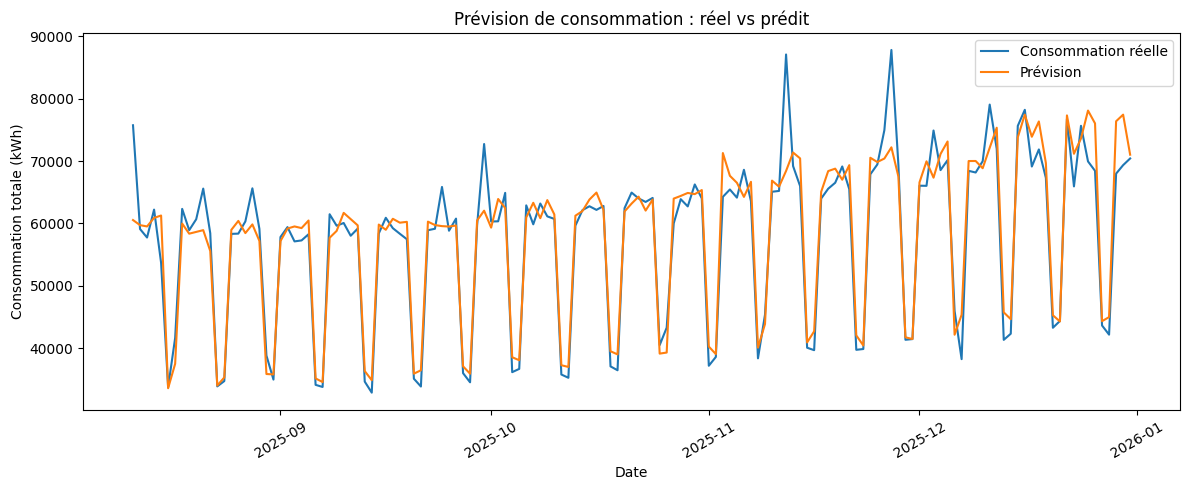

In [24]:
plot_df = (
    predictions_df
    .groupby("date", as_index=False)[
        ["consommation_totale_kwh", "prediction_kwh"]
    ]
    .sum()
)

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["date"],
    plot_df["consommation_totale_kwh"],
    label="Consommation réelle"
)

plt.plot(
    plot_df["date"],
    plot_df["prediction_kwh"],
    label="Prévision"
)

plt.title("Prévision de consommation : réel vs prédit")
plt.xlabel("Date")
plt.ylabel("Consommation totale (kWh)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 18. Importance des variables

lag_7j                    0.517704
lag_14j                   0.192463
rolling_7j                0.143841
zone_Zone-Industrielle    0.100504
jour_semaine              0.019421
temp_max_c                0.005240
temp_moyenne_c            0.004942
temp_min_c                0.004767
lag_1j                    0.003670
dju_chauffage             0.003500
dtype: float64

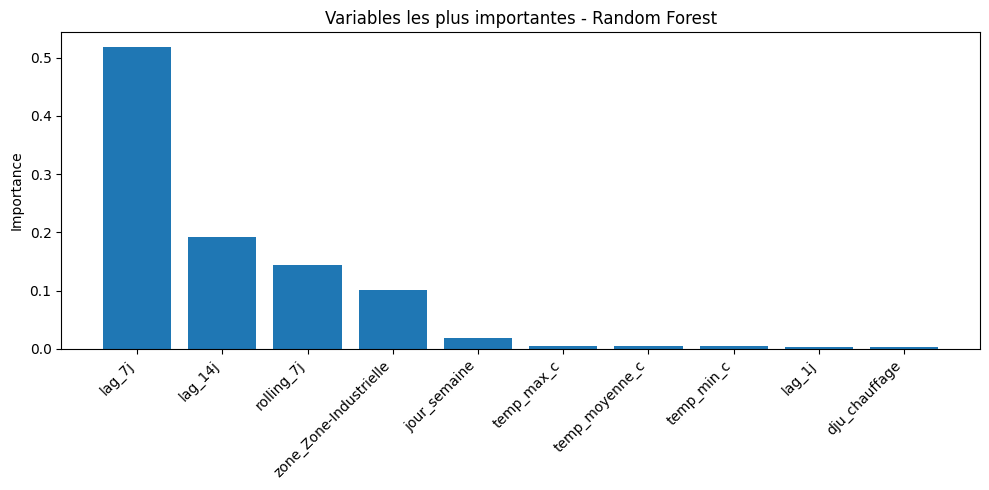

In [25]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

display(importances)

plt.figure(figsize=(10, 5))
plt.bar(importances.index, importances.values)
plt.title("Variables les plus importantes - Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 19. Export des résultats


In [26]:
metrics_path = OUTPUT_DIR / "metrics.txt"
predictions_path = OUTPUT_DIR / "predictions.csv"

with open(metrics_path, "w", encoding="utf-8") as file:
    file.write("US6 - Modèle de prévision de consommation\n")
    file.write("=========================================\n\n")
    file.write(f"Meilleur modèle : {best_model_name}\n\n")
    file.write(results_df.to_string(index=False))

predictions_df.to_csv(predictions_path, index=False)

print("Fichier métriques créé :", metrics_path)
print("Fichier prédictions créé :", predictions_path)

Fichier métriques créé : C:\Users\iness\PycharmProjects\PythonProject2\Neovolt-grid-project\volet-datascience\data\output\metrics.txt
Fichier prédictions créé : C:\Users\iness\PycharmProjects\PythonProject2\Neovolt-grid-project\volet-datascience\data\output\predictions.csv


## 20. Conclusion intermédiaire


In [30]:
best_mape = results_df.iloc[0]["MAPE_%"]

print(f"Le meilleur modèle est {best_model_name} avec un MAPE de {best_mape:.2f} %.")

if best_mape < 10:
    print("L'objectif d'un écart moyen inférieur à 10 % est atteint.")
else:
    print("L'objectif d'un écart moyen inférieur à 10 % n'est pas encore atteint.")

Le meilleur modèle est Random Forest avec un MAPE de 8.64 %.
L'objectif d'un écart moyen inférieur à 10 % est atteint.
